# NuChef Vision Model Bake‑Off (Detection + Tracking + CNN Baselines)

This notebook is a **comparison harness** for ingredient recognition approaches:

1. **YOLOv11 baseline** (pretrained weights or your current checkpoint)  
2. **YOLOv11 fine‑tuned** on your ingredient dataset (det or seg; single-pass localization + classification)  
3. **CNN crop classifier baseline** (e.g., ResNet18 / EfficientNet / MobileNet / custom small CNN) trained on GT crops  
4. **Tracking + temporal smoothing** to reduce compute (run detector every *N* frames, track in between)

It produces a **Performance Table** for quick side‑by‑side comparison.


---

## 0) Setup / Install

If you're in Colab, you can optionally mount Google Drive.


In [3]:
# (Optional) Colab drive mount
# from google.colab import drive
# drive.mount("/content/drive")

# (Optional) installs (uncomment if needed)
# !pip install -U ultralytics opencv-python torch torchvision torchaudio pandas numpy tqdm pyyaml

import os, time, math, random, shutil
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import yaml
import cv2

SEED = 445
random.seed(SEED); np.random.seed(SEED)

print("OK: imports loaded")


OK: imports loaded


In [4]:
import torch; print('CUDA available:', torch.cuda.is_available())
print('PyTorch version:', torch.__version__)
print('Device name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')

CUDA available: True
PyTorch version: 2.10.0+cu128
Device name: NVIDIA GeForce RTX 3080 Ti Laptop GPU


## 1) Config

Point `DATA_YAML` to your Ultralytics/YOLO dataset `data.yaml`.

Expected YOLO layout (typical):
```
dataset/
  train/images/*.jpg
  train/labels/*.txt
  val/images/*.jpg
  val/labels/*.txt
  test/images/*.jpg
  test/labels/*.txt
  data.yaml
```


In [5]:

# =====================
# EDIT THESE
# =====================
DATA_YAML = os.environ.get("NUCHEF_DATA_YAML", "data/data.yaml")

# YOLO weights you want to compare
YOLO_BASE_WEIGHTS = os.environ.get("NUCHEF_YOLO_BASE", "yolo11n.pt")         # baseline
YOLO_FT_WEIGHTS   = os.environ.get("NUCHEF_YOLO_FT",   "PATH/TO/best.pt")    # fine-tuned (optional)

# Evaluation split
EVAL_SPLIT = "test"   # "val" or "test"

# Detector thresholds for evaluation
CONF_THRESH = 0.25
IOU_THRESH  = 0.50

# For speed benchmarking (timing), we skip the first few warmup inferences
WARMUP_ITERS = 5

print("DATA_YAML:", DATA_YAML)
print("YOLO_BASE_WEIGHTS:", YOLO_BASE_WEIGHTS)
print("YOLO_FT_WEIGHTS:", YOLO_FT_WEIGHTS)
print("EVAL_SPLIT:", EVAL_SPLIT, "CONF_THRESH:", CONF_THRESH, "IOU_THRESH:", IOU_THRESH)


DATA_YAML: data/data.yaml
YOLO_BASE_WEIGHTS: yolo11n.pt
YOLO_FT_WEIGHTS: PATH/TO/best.pt
EVAL_SPLIT: test CONF_THRESH: 0.25 IOU_THRESH: 0.5


## 2) Helper: read dataset info + list images

We will:
- read `names:` from `data.yaml`
- find the image directory for the chosen split
- infer the matching label directory (replace `/images/` with `/labels/`)


In [6]:

def load_yolo_yaml(data_yaml: str) -> dict:
    with open(data_yaml, "r", encoding="utf-8") as f:
        y = yaml.safe_load(f)
    return y

def yolo_names(y: dict) -> List[str]:
    names = y.get("names")
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]
    if not isinstance(names, list):
        raise ValueError("data.yaml missing a valid `names:` list/dict")
    return names

from pathlib import Path

# Load yaml FIRST so we can use `y` below
y = load_yolo_yaml(DATA_YAML)

DATA_YAML_PATH = Path(DATA_YAML).resolve()
DATA_BASE = Path(y.get("path", DATA_YAML_PATH.parent)).resolve()

def resolve_split_dir(y: dict, split: str) -> Path:
    """Resolve the image directory for a split, using the yaml's own `path` key."""
    # handle "valid" vs "val"
    key = split
    if split == "valid" and "valid" not in y and "val" in y:
        key = "val"
    if split == "val" and "val" not in y and "valid" in y:
        key = "valid"
    rel = Path(y[key])
    # Use the yaml's own `path` field if present; fall back to global DATA_BASE
    base = Path(y["path"]).resolve() if "path" in y else DATA_BASE
    return (base / rel).resolve()

def infer_labels_dir(images_dir: Path) -> Path:
    # typical structure: .../train/images -> .../train/labels
    parts = list(images_dir.parts)
    if "images" in parts:
        i = parts.index("images")
        parts[i] = "labels"
        return Path(*parts)
    # fallback: sibling folder called labels
    return images_dir.parent / "labels"

def list_images(images_dir: Path, exts=(".jpg",".jpeg",".png",".bmp",".webp")) -> List[Path]:
    out = []
    for e in exts:
        out += list(images_dir.rglob(f"*{e}"))
    return sorted(out)

CLASS_NAMES = yolo_names(y)
images_dir = resolve_split_dir(y, EVAL_SPLIT)
labels_dir = infer_labels_dir(images_dir)

print("Classes:", len(CLASS_NAMES))
print("Images dir:", images_dir)
print("Labels dir:", labels_dir)

IMG_PATHS = list_images(images_dir)
print("Num images:", len(IMG_PATHS))
print("Example:", IMG_PATHS[0] if IMG_PATHS else None)


Classes: 13
Images dir: /home/tony/CS444/CS444/NuChef_1_1/data/test/images
Labels dir: /home/tony/CS444/CS444/NuChef_1_1/data/test/labels
Num images: 115
Example: /home/tony/CS444/CS444/NuChef_1_1/data/test/images/041_PNG_jpg.rf.7dc4d58422360d9f218b92748741da89.jpg


## 3) Redefine target: choose Top‑K ingredients (+ unknown)

You can:
- manually list your “core” 30–50 ingredients, **or**
- auto‑suggest candidates by **class frequency** (how often each label appears in GT)

This helps you focus training/eval on what you can reliably recognize.


In [7]:
def parse_yolo_label_file_generic(txt_path: Path) -> List[Tuple[int, List[float]]]:
    # Works for YOLO-det labels (cls xc yc w h) and YOLO-seg labels (cls x1 y1 x2 y2 ...).
    # Returns: list of (cls_id, rest_floats)
    if not txt_path.exists():
        return []
    rows = []
    for line in txt_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        cls = int(float(parts[0]))
        rest = [float(x) for x in parts[1:]]
        rows.append((cls, rest))
    return rows

def class_frequency(img_paths: List[Path], labels_dir: Path, class_names: List[str]) -> pd.Series:
    counts = np.zeros(len(class_names), dtype=np.int64)
    for img in img_paths:
        txt = labels_dir / (img.stem + ".txt")
        for cls, _ in parse_yolo_label_file_generic(txt):
            if 0 <= cls < len(counts):
                counts[cls] += 1
    return pd.Series(counts, index=class_names).sort_values(ascending=False)

freq = class_frequency(IMG_PATHS, labels_dir, CLASS_NAMES)
display(freq.head(20))

TOPK = 50  # change to 30..50
SUGGESTED_CORE = list(freq.head(TOPK).index)
print("Suggested core classes (top by GT frequency):")
print(SUGGESTED_CORE)


Bell Pepper    44
Onion          42
Apple          38
Carrot         30
Egg            25
Tomato         24
Broccoli       22
Banana         20
Cauliflower    11
Courgette      10
Eggplant        7
Milk            6
Pasta           3
dtype: int64

Suggested core classes (top by GT frequency):
['Bell Pepper', 'Onion', 'Apple', 'Carrot', 'Egg', 'Tomato', 'Broccoli', 'Banana', 'Cauliflower', 'Courgette', 'Eggplant', 'Milk', 'Pasta']


### 3B) Create a filtered dataset (core + optional unknown)

This **writes a new dataset folder** where labels are remapped to:
- keep only `CORE_CLASSES` (dropping the rest), or
- map the rest into an `"unknown"` class.


In [8]:

CORE_CLASSES = SUGGESTED_CORE  # <-- replace with your chosen 30–50 list if you want

OUT_DATASET_DIR = Path("filtered_dataset_core").resolve()
ADD_UNKNOWN = True         # map non-core labels to "unknown"
DROP_NONCORE = False       # if True, drops non-core objects instead of mapping to unknown

def safe_link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if dst.exists():
            return
        os.link(src, dst)  # hardlink (fast, no extra space)
    except Exception:
        shutil.copy2(src, dst)

def make_filtered_dataset(data_yaml: str, out_dir: Path, core_classes: List[str],
                          add_unknown: bool = True, drop_noncore: bool = False) -> Path:
    y = load_yolo_yaml(data_yaml)
    names = yolo_names(y)
    name_to_id = {n:i for i,n in enumerate(names)}

    # new class list
    new_names = list(core_classes)
    unknown_id = None
    if drop_noncore:
        add_unknown = False
    if add_unknown:
        unknown_id = len(new_names)
        new_names.append("unknown")

    core_ids = {name_to_id[n] for n in core_classes if n in name_to_id}
    new_name_to_id = {n:i for i,n in enumerate(new_names)}

    def remap_cls(old_cls: int) -> Optional[int]:
        if old_cls in core_ids:
            return new_name_to_id[names[old_cls]]
        if add_unknown and unknown_id is not None:
            return unknown_id
        return None  # drop

    out_dir.mkdir(parents=True, exist_ok=True)

    # write new yaml
    new_yaml = dict(y)
    new_yaml["path"] = str(out_dir)
    new_yaml["names"] = new_names
    new_yaml["nc"] = len(new_names)  # <-- keep nc in sync with names
    for split_key in ["train","val","valid","test"]:
        if split_key in new_yaml:
            new_yaml[split_key] = str(Path(new_yaml[split_key]))

    # copy/link images + rewrite labels
    for split in ["train","val","valid","test"]:
        if split not in y:
            continue
        img_dir = resolve_split_dir(y, split)
        lbl_dir = infer_labels_dir(img_dir)

        out_img_dir = out_dir / Path(y[split])
        out_lbl_dir = infer_labels_dir(out_img_dir)

        imgs = list_images(img_dir)
        for img in imgs:
            out_img = out_img_dir / img.relative_to(img_dir)
            safe_link_or_copy(img, out_img)

            txt = lbl_dir / (img.stem + ".txt")
            rows = parse_yolo_label_file_generic(txt)
            new_lines = []
            for cls_id, rest in rows:
                new_id = remap_cls(cls_id)
                if new_id is None:
                    continue
                new_lines.append(str(new_id) + " " + " ".join(str(x) for x in rest))

            out_txt = out_lbl_dir / (img.stem + ".txt")
            out_txt.parent.mkdir(parents=True, exist_ok=True)
            out_txt.write_text("\n".join(new_lines) + ("\n" if new_lines else ""), encoding="utf-8")

    out_yaml_path = out_dir / "data.yaml"
    out_yaml_path.write_text(yaml.safe_dump(new_yaml, sort_keys=False), encoding="utf-8")
    return out_yaml_path

FILTERED_YAML = make_filtered_dataset(DATA_YAML, OUT_DATASET_DIR, CORE_CLASSES,
                                      add_unknown=ADD_UNKNOWN, drop_noncore=DROP_NONCORE)
print("Wrote filtered dataset yaml:", FILTERED_YAML)
print("Filtered class count:", len(yolo_names(load_yolo_yaml(str(FILTERED_YAML)))))


Wrote filtered dataset yaml: /home/tony/CS444/CS444/NuChef_1_1/filtered_dataset_core/data.yaml
Filtered class count: 14


NameError: name 'yolo_names' is not defined

## 4) Train YOLOv11 (det or seg)

Run this when you want to fine‑tune a YOLOv11 model on your dataset.


In [ ]:
from ultralytics import YOLO

# Absolute path so runs always land inside this project folder
RUNS_DIR = str(Path(".").resolve() / "runs")

def train_yolo_ultralytics(weights, data_yaml, task="detect",
                           epochs=50, imgsz=640, batch=16, device="0",
                           project=RUNS_DIR, name="exp"):
    model = YOLO(weights, task=task)
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        device=device,
        project=project,
        name=name,
        workers=8,
        cache="ram",
    )
    best = Path(project) / name / "weights" / "best.pt"
    print("Best checkpoint:", best)
    return str(best)

# Train on the original 13-class dataset:
YOLO_FT_WEIGHTS = train_yolo_ultralytics(
    weights=YOLO_BASE_WEIGHTS,
    data_yaml=DATA_YAML,
    task="detect",
    epochs=50,
    imgsz=640,
    batch=-1,       # auto max batch
    device="0",
    project=RUNS_DIR,
    name="yolo11n_ingredients_det_ft"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080 Ti Laptop GPU, 15976MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/tony/CS444/CS444/NuChef_1_1/filtered_dataset_core/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_ingredients_det_ft, nbs=64, nms=False, opset=N

In [1]:

# --- Export fine-tuned detect model to ONNX (no embedded NMS) ---
from ultralytics import YOLO
from pathlib import Path

# Point to your fine-tuned detection weights
YOLO_FT_WEIGHTS = str(Path("runs/detect/runs/yolo11n_ingredients_det_ft/weights/best.pt").resolve())

model = YOLO(YOLO_FT_WEIGHTS, task="detect")

# Export to ONNX — nms=False keeps the raw output (no TFLite/end2end NMS block)
model.export(
    format="onnx",
    imgsz=640,
    opset=17,          # broad compatibility; lower to 12/13 if needed
    simplify=True,     # runs onnx-simplifier
    nms=False,         # ← no embedded NMS post-processing
    dynamic=False,     # set True if you want dynamic batch/img size
    half=False,        # set True for FP16 export
)

print("Exported ONNX (no NMS) next to the .pt file")


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (12th Gen Intel Core i9-12900HK)
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_ingredients_det_ft/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (5.2 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 0.8s, saved as '/home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_ingredients_det_ft/weights/best.onnx' (10.1 MB)

Export complete (0.9s)
Results saved to /home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_ingredients_det_ft/weights
Predict:         yolo predict task=detect model=/home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_ingredients_det_ft/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_i

## 5) Evaluation (Detection): instance Precision / Recall / F1 + Inference Time

We compute instance TP/FP/FN by greedy matching (IoU ≥ threshold).

- **Accuracy** here is a detection-style proxy: `TP / (TP + FP + FN)`.


In [9]:
@dataclass
class Det:
    bbox: Tuple[float,float,float,float]   # xyxy
    cls: int
    conf: float

def iou_xyxy(a, b) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw*ih
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = area_a + area_b - inter
    return float(inter/union) if union > 0 else 0.0

def greedy_match(gts: List[Det], preds: List[Det], iou_thresh: float) -> Tuple[int,int,int]:
    preds = sorted(preds, key=lambda d: d.conf, reverse=True)
    matched = set()
    TP = FP = 0
    for p in preds:
        best_iou, best_j = 0.0, None
        for j, gt in enumerate(gts):
            if j in matched:
                continue
            i = iou_xyxy(gt.bbox, p.bbox)
            if i > best_iou:
                best_iou, best_j = i, j
        if best_j is not None and best_iou >= iou_thresh and p.cls == gts[best_j].cls:
            TP += 1
            matched.add(best_j)
        else:
            FP += 1
    FN = len(gts) - len(matched)
    return TP, FP, FN

def metrics_from_counts(TP, FP, FN) -> Dict[str,float]:
    precision = TP / (TP+FP) if (TP+FP) else 0.0
    recall    = TP / (TP+FN) if (TP+FN) else 0.0
    f1        = (2*precision*recall/(precision+recall)) if (precision+recall) else 0.0
    acc       = TP / (TP+FP+FN) if (TP+FP+FN) else 0.0
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

def parse_gt_bboxes(txt_path: Path, img_w: int, img_h: int) -> List[Det]:
    """Parse GT labels — handles BOTH detection (xc yc w h) and segmentation (polygon) formats."""
    gts = []
    for cls, rest in parse_yolo_label_file_generic(txt_path):
        if len(rest) < 4:
            continue
        if len(rest) == 4:
            # YOLO-det format: xc yc w h (normalised)
            xc, yc, bw, bh = rest
            xc *= img_w; yc *= img_h; bw *= img_w; bh *= img_h
            x1 = xc - bw/2; y1 = yc - bh/2; x2 = xc + bw/2; y2 = yc + bh/2
        else:
            # YOLO-seg format: x1 y1 x2 y2 ... (polygon vertices, normalised)
            xs = [rest[i] * img_w for i in range(0, len(rest), 2)]
            ys = [rest[i] * img_h for i in range(1, len(rest), 2)]
            x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
        gts.append(Det((x1, y1, x2, y2), cls, 1.0))
    return gts

In [20]:
from ultralytics import YOLO

def evaluate_yolo_instance_metrics(weights: str, data_yaml: str, split: str,
                                   conf: float = 0.25, iou: float = 0.50,
                                   warmup: int = 5, max_images: Optional[int] = None) -> Dict[str,float]:
    y = load_yolo_yaml(data_yaml)
    img_dir = resolve_split_dir(y, split)
    lbl_dir = infer_labels_dir(img_dir)
    img_paths = list_images(img_dir)
    if max_images is not None:
        img_paths = img_paths[:max_images]

    model = YOLO(weights)

    # warmup
    for p in img_paths[:min(warmup, len(img_paths))]:
        _ = model.predict(source=str(p), conf=conf, iou=iou, verbose=False)

    TP=FP=FN=0
    times = []

    for img_path in img_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        gt_txt = lbl_dir / (img_path.stem + ".txt")
        gts = parse_gt_bboxes(gt_txt, w, h)

        t0 = time.perf_counter()
        preds = model.predict(source=str(img_path), conf=conf, iou=iou, verbose=False)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

        r = preds[0]
        pred_dets = []
        if r.boxes is not None and len(r.boxes) > 0:
            xyxy = r.boxes.xyxy.cpu().numpy()
            cls  = r.boxes.cls.cpu().numpy().astype(int)
            cf   = r.boxes.conf.cpu().numpy()
            for bb, c, confv in zip(xyxy, cls, cf):
                pred_dets.append(Det(tuple(map(float, bb)), int(c), float(confv)))

        tpi, fpi, fni = greedy_match(gts, pred_dets, iou_thresh=iou)
        TP += tpi; FP += fpi; FN += fni

    m = metrics_from_counts(TP, FP, FN)
    m["inference_ms"] = float(np.mean(times)) if times else float("nan")
    m["num_images"] = len(img_paths)
    m["TP"] = TP; m["FP"] = FP; m["FN"] = FN
    return m

# The FT model was trained on filtered_dataset_core (14 classes, reordered by frequency).
# It MUST be evaluated against the same dataset so class IDs match.
# The baseline yolo11n.pt is COCO-pretrained (80 classes) — its class IDs don't
# correspond to ingredient IDs, so baseline eval is not meaningful here.

YOLO_FT_WEIGHTS = str(Path("runs/detect/runs/yolo11n_ingredients_det_ft/weights/best.pt").resolve())
print("YOLO_FT_WEIGHTS:", YOLO_FT_WEIGHTS)

# Evaluate FT model against the FILTERED dataset it was trained on
ft_metrics = evaluate_yolo_instance_metrics(YOLO_FT_WEIGHTS, str(FILTERED_YAML), EVAL_SPLIT, conf=CONF_THRESH, iou=IOU_THRESH)
print("YOLO FT:", ft_metrics)

YOLO_FT_WEIGHTS: /home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_ingredients_det_ft/weights/best.pt
YOLO FT: {'accuracy': 0.8085106382978723, 'precision': 0.8498402555910544, 'recall': 0.9432624113475178, 'f1': 0.8941176470588236, 'inference_ms': 5.462308930114175, 'num_images': 115, 'TP': 266, 'FP': 47, 'FN': 16}


## 6) CNN Crop Classifier Baseline (Classification)

This baseline trains a classifier on **GT crops** generated from your YOLO labels.
It answers: “If I already have good boxes, how good can classification be?”

Steps:
1. Create crops from GT boxes into `crops_dataset/{split}/{class_name}/*.jpg`
2. Train a classifier (ResNet18 / EfficientNet / MobileNet / ...)
3. Evaluate Accuracy / Precision / Recall / F1 + inference time per crop


In [10]:
CROPS_DIR = Path("crops_dataset").resolve()
CROP_SIZE = 224

def xyxy_clip(bb, w, h):
    x1,y1,x2,y2 = bb
    x1 = int(max(0, min(w-1, x1)))
    y1 = int(max(0, min(h-1, y1)))
    x2 = int(max(0, min(w,   x2)))
    y2 = int(max(0, min(h,   y2)))
    if x2 <= x1 or y2 <= y1:
        return None
    return x1,y1,x2,y2

def make_gt_crops(data_yaml: str, out_dir: Path, split: str, crop_size: int = 224, max_images: Optional[int] = None):
    y = load_yolo_yaml(data_yaml)
    names = yolo_names(y)

    img_dir = resolve_split_dir(y, split)
    lbl_dir = infer_labels_dir(img_dir)
    img_paths = list_images(img_dir)
    if max_images is not None:
        img_paths = img_paths[:max_images]

    for p in img_paths:
        img = cv2.imread(str(p))
        if img is None:
            continue
        h,w = img.shape[:2]
        gt_txt = lbl_dir / (p.stem + ".txt")
        gts = parse_gt_bboxes(gt_txt, w, h)

        for k, gt in enumerate(gts):
            bb = xyxy_clip(gt.bbox, w, h)
            if bb is None:
                continue
            x1,y1,x2,y2 = bb
            crop = img[y1:y2, x1:x2]
            crop = cv2.resize(crop, (crop_size, crop_size), interpolation=cv2.INTER_AREA)
            cls_name = names[gt.cls] if 0 <= gt.cls < len(names) else "unknown"
            out_path = out_dir / split / cls_name / f"{p.stem}_{k}.jpg"
            out_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(out_path), crop)

print("Crops dir:", CROPS_DIR)
# Example:
make_gt_crops(str(FILTERED_YAML), CROPS_DIR, split="train", crop_size=CROP_SIZE)
make_gt_crops(str(FILTERED_YAML), CROPS_DIR, split=EVAL_SPLIT, crop_size=CROP_SIZE)


Crops dir: /home/tony/CS444/CS444/NuChef_1_1/crops_dataset


In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

def build_dataloaders(crops_dir: Path, train_split="train", test_split="test", batch_size=64):
    tfm_train = transforms.Compose([
        transforms.RandomResizedCrop(CROP_SIZE, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
    ])
    tfm_test = transforms.Compose([
        transforms.Resize((CROP_SIZE, CROP_SIZE)),
        transforms.ToTensor(),
    ])
    train_ds = datasets.ImageFolder(str(crops_dir / train_split), transform=tfm_train)
    test_ds  = datasets.ImageFolder(str(crops_dir / test_split),  transform=tfm_test)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_ds, test_ds, train_dl, test_dl

def build_classifier(model_name: str, num_classes: int) -> nn.Module:
    name = model_name.lower()
    if name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    if name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
        return m
    raise ValueError(f"Unknown model_name: {model_name}")

@torch.no_grad()
def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> Dict[str,float]:
    # macro precision/recall/f1
    eps = 1e-9
    tp = np.zeros(num_classes, dtype=np.float64)
    fp = np.zeros(num_classes, dtype=np.float64)
    fn = np.zeros(num_classes, dtype=np.float64)
    for c in range(num_classes):
        tp[c] = np.sum((y_pred==c) & (y_true==c))
        fp[c] = np.sum((y_pred==c) & (y_true!=c))
        fn[c] = np.sum((y_pred!=c) & (y_true==c))
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = 2*prec*rec / (prec + rec + eps)
    acc  = float(np.mean(y_pred==y_true)) if len(y_true) else 0.0
    return {"accuracy": acc, "precision": float(np.mean(prec)), "recall": float(np.mean(rec)), "f1": float(np.mean(f1))}

def train_classifier(model_name="resnet18", epochs=5, lr=1e-3, batch_size=64,
                     device=None, train_split="train", test_split="test"):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    train_ds, test_ds, train_dl, test_dl = build_dataloaders(CROPS_DIR, train_split, test_split, batch_size=batch_size)

    model = build_classifier(model_name, num_classes=len(train_ds.classes)).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        pbar = tqdm(train_dl, desc=f"{model_name} epoch {ep+1}/{epochs}")
        for xb, yb in pbar:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            pbar.set_postfix(loss=float(loss.detach().cpu()))

    model.eval()
    ys, ps = [], []
    times = []
    warmup = 1  # only skip 1 batch for warmup (small test set)
    for i, (xb, yb) in enumerate(test_dl):
        xb = xb.to(device)
        t0 = time.perf_counter()
        logits = model(xb)
        t1 = time.perf_counter()
        if i >= warmup:
            times.append((t1-t0)*1000.0/xb.shape[0])  # ms per crop
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(pred)

    y_true = np.concatenate(ys) if ys else np.array([])
    y_pred = np.concatenate(ps) if ps else np.array([])
    m = classification_metrics(y_true, y_pred, num_classes=len(train_ds.classes))
    m["inference_ms"] = float(np.mean(times)) if times else float("nan")
    m["num_samples"] = int(len(test_ds))
    m["classes"] = list(train_ds.classes)
    return model, m

# Generate crops + train CNN classifier
make_gt_crops(str(FILTERED_YAML), CROPS_DIR, split="train", crop_size=CROP_SIZE)
make_gt_crops(str(FILTERED_YAML), CROPS_DIR, split=EVAL_SPLIT, crop_size=CROP_SIZE)
model, cnn_metrics = train_classifier("resnet18", epochs=15, lr=1e-3, batch_size=64, train_split="train", test_split=EVAL_SPLIT)
print(cnn_metrics)

/home/tony/anaconda3/envs/CS444/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
resnet18 epoch 15/15: 100%|██████████| 37/37 [00:05<00:00,  6.82it/s, loss=0.0133] 


{'accuracy': 0.9184397163120568, 'precision': 0.9300734131454094, 'recall': 0.9230373134823588, 'f1': 0.923959529103215, 'inference_ms': 0.4079146607579832, 'num_samples': 282, 'classes': ['Apple', 'Banana', 'Bell Pepper', 'Broccoli', 'Carrot', 'Cauliflower', 'Courgette', 'Egg', 'Eggplant', 'Milk', 'Onion', 'Pasta', 'Tomato']}


In [30]:
# --- Evaluate CNN classifier on test crops ---
from torchvision import datasets, transforms

tfm_test = transforms.Compose([
    transforms.Resize((CROP_SIZE, CROP_SIZE)),
    transforms.ToTensor(),
])

test_ds = datasets.ImageFolder(str(CROPS_DIR / EVAL_SPLIT), transform=tfm_test)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

ys, ps, times = [], [], []
with torch.no_grad():
    for i, (xb, yb) in enumerate(test_dl):
        xb = xb.to(device)
        t0 = time.perf_counter()
        logits = model(xb)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0 / xb.shape[0])  # ms per crop
        ps.append(torch.argmax(logits, dim=1).cpu().numpy())
        ys.append(yb.numpy())

y_true = np.concatenate(ys)
y_pred = np.concatenate(ps)

cnn_eval = classification_metrics(y_true, y_pred, num_classes=len(test_ds.classes))
cnn_eval["inference_ms"] = float(np.mean(times))
cnn_eval["num_samples"] = len(test_ds)

print(f"CNN (ResNet18) on {EVAL_SPLIT} crops:")
print(f"  Accuracy:  {cnn_eval['accuracy']*100:.1f}%")
print(f"  Precision: {cnn_eval['precision']*100:.1f}% (macro)")
print(f"  Recall:    {cnn_eval['recall']*100:.1f}% (macro)")
print(f"  F1:        {cnn_eval['f1']:.4f} (macro)")
print(f"  Inference: {cnn_eval['inference_ms']:.3f} ms/crop")
print(f"  Samples:   {cnn_eval['num_samples']}")
print(f"  Classes:   {test_ds.classes}")

CNN (ResNet18) on test crops:
  Accuracy:  86.5%
  Precision: 90.7% (macro)
  Recall:    82.3% (macro)
  F1:        0.8480 (macro)
  Inference: 0.042 ms/crop
  Samples:   282
  Classes:   ['Apple', 'Banana', 'Bell Pepper', 'Broccoli', 'Carrot', 'Cauliflower', 'Courgette', 'Egg', 'Eggplant', 'Milk', 'Onion', 'Pasta', 'Tomato']


## 7) Tracking + Temporal Smoothing (run detector every N frames)

Lightweight IOU-based tracker (no external deps) plus:
- EMA box smoothing
- confidence-weighted class vote over last K frames

Use this to measure effective FPS / per-frame time.


In [27]:
@dataclass
class Track:
    track_id: int
    bbox: Tuple[float,float,float,float]
    cls_hist: List[int] = field(default_factory=list)
    conf_hist: List[float] = field(default_factory=list)
    age: int = 0
    missed: int = 0

class IoUTracker:
    def __init__(self, iou_thresh=0.3, max_missed=10, ema_alpha=0.7, smooth_k=7):
        self.iou_thresh = iou_thresh
        self.max_missed = max_missed
        self.ema_alpha = ema_alpha
        self.smooth_k = smooth_k
        self.tracks: Dict[int, Track] = {}
        self._next_id = 1

    def _smooth_bbox(self, old, new):
        a = self.ema_alpha
        return tuple(a*o + (1-a)*n for o,n in zip(old,new))

    def _smooth_cls(self, t: Track) -> int:
        k = self.smooth_k
        cls = t.cls_hist[-k:]
        conf= t.conf_hist[-k:]
        score = {}
        for c, w in zip(cls, conf):
            score[c] = score.get(c, 0.0) + float(w)
        return max(score.items(), key=lambda kv: kv[1])[0] if score else -1

    def update(self, detections: List[Det]) -> List[Track]:
        for t in self.tracks.values():
            t.age += 1
            t.missed += 1

        dets = detections[:]
        pairs = []
        for tid, t in self.tracks.items():
            for i, d in enumerate(dets):
                pairs.append((tid, i, iou_xyxy(t.bbox, d.bbox)))
        pairs.sort(key=lambda x: x[2], reverse=True)

        used_tracks = set()
        used_dets = set()

        for tid, i, iouval in pairs:
            if iouval < self.iou_thresh:
                break
            if tid in used_tracks or i in used_dets:
                continue
            tr = self.tracks[tid]
            tr.bbox = self._smooth_bbox(tr.bbox, dets[i].bbox)
            tr.cls_hist.append(dets[i].cls)
            tr.conf_hist.append(dets[i].conf)
            tr.missed = 0
            used_tracks.add(tid)
            used_dets.add(i)

        for i, d in enumerate(dets):
            if i in used_dets:
                continue
            tid = self._next_id; self._next_id += 1
            self.tracks[tid] = Track(track_id=tid, bbox=d.bbox, cls_hist=[d.cls], conf_hist=[d.conf], age=1, missed=0)

        dead = [tid for tid,t in self.tracks.items() if t.missed > self.max_missed]
        for tid in dead:
            del self.tracks[tid]

        out = []
        for t in self.tracks.values():
            sm_cls = self._smooth_cls(t)
            out.append(Track(track_id=t.track_id, bbox=t.bbox, cls_hist=[sm_cls], conf_hist=t.conf_hist[-1:], age=t.age, missed=t.missed))
        return out


In [ ]:
def run_video_benchmark(video_path: str, weights: str, detect_every: int = 5,
                        conf: float = 0.25, iou: float = 0.50,
                        max_frames: Optional[int] = 300,
                        out_video: Optional[str] = None) -> Dict[str,float]:
    model = YOLO(weights)
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Could not open video: {video_path}"

    tracker = IoUTracker(iou_thresh=0.3, max_missed=10, ema_alpha=0.7, smooth_k=7)

    writer = None
    if out_video is not None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        writer = cv2.VideoWriter(out_video, fourcc, fps, (w,h))

    frame_idx = 0
    times = []
    det_times = []
    track_times = []

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if max_frames and frame_idx > max_frames:
            break

        t0 = time.perf_counter()

        detections = []
        if (frame_idx % detect_every) == 1:
            td0 = time.perf_counter()
            preds = model.predict(source=frame, conf=conf, iou=iou, verbose=False)
            td1 = time.perf_counter()
            det_times.append((td1-td0)*1000.0)
            r = preds[0]
            if r.boxes is not None and len(r.boxes) > 0:
                xyxy = r.boxes.xyxy.cpu().numpy()
                cls  = r.boxes.cls.cpu().numpy().astype(int)
                cf   = r.boxes.conf.cpu().numpy()
                for bb, c, confv in zip(xyxy, cls, cf):
                    detections.append(Det(tuple(map(float, bb)), int(c), float(confv)))

        tt0 = time.perf_counter()
        tracks = tracker.update(detections)
        tt1 = time.perf_counter()
        track_times.append((tt1-tt0)*1000.0)

        if writer is not None:
            draw = frame.copy()
            for tr in tracks:
                x1,y1,x2,y2 = map(int, tr.bbox)
                cv2.rectangle(draw, (x1,y1), (x2,y2), (0,255,0), 2)
                label = f"ID{tr.track_id} cls{tr.cls_hist[0]}"
                cv2.putText(draw, label, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
            writer.write(draw)

        t1 = time.perf_counter()
        times.append((t1-t0)*1000.0)

    cap.release()
    if writer is not None:
        writer.release()

    avg_ms = float(np.mean(times)) if times else float("nan")
    fps_eff = 1000.0/avg_ms if avg_ms and not math.isnan(avg_ms) else float("nan")
    return {
        "avg_frame_ms": avg_ms,
        "fps": fps_eff,
        "avg_detect_ms": float(np.mean(det_times)) if det_times else float("nan"),
        "avg_track_ms": float(np.mean(track_times)) if track_times else float("nan"),
        "frames": frame_idx
    }

# Uncomment and set a real video path to run:
# vid_metrics = run_video_benchmark("PATH/TO/demo.mp4", YOLO_FT_WEIGHTS, detect_every=5, out_video="tracked_out.mp4")
# print(vid_metrics)

## 8) Performance Table (as requested)

Creates/updates a table like:

| Model Name | Dataset | Accuracy (%) | Precision (%) | Recall (%) | F1 Score | Inference Time (ms) | Notes |


In [ ]:
PERF_TABLE_PATH = Path("performance_table.csv").resolve()

COLUMNS = ["Model Name", "Dataset", "Accuracy (%)", "Precision (%)", "Recall (%)",
           "F1 Score", "Inference Time (ms)", "Notes"]

def load_or_init_table(path: Path) -> pd.DataFrame:
    if path.exists():
        df = pd.read_csv(path)
        for c in COLUMNS:
            if c not in df.columns:
                df[c] = ""
        return df[COLUMNS]
    return pd.DataFrame(columns=COLUMNS)

def add_result(df: pd.DataFrame, model_name: str, dataset: str, m: Dict[str,float], notes: str = "") -> pd.DataFrame:
    row = {
        "Model Name": model_name,
        "Dataset": dataset,
        "Accuracy (%)": round(100.0*float(m.get("accuracy", 0.0)), 2),
        "Precision (%)": round(100.0*float(m.get("precision", 0.0)), 2),
        "Recall (%)": round(100.0*float(m.get("recall", 0.0)), 2),
        "F1 Score": round(float(m.get("f1", 0.0)), 4),
        "Inference Time (ms)": round(float(m.get("inference_ms", float("nan"))), 3),
        "Notes": notes
    }
    return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

def save_table(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False)
    print("Saved:", path)

df_perf = load_or_init_table(PERF_TABLE_PATH)
df_perf


In [20]:
# Populate performance table with results from Section 8 evaluation
# ft_metrics  → mAP@0.50:0.95 from YOLO val (best_2.pt on original 13-class data.yaml)
# cnn_metrics → top-1 accuracy from ResNet18 trained for 15 epochs on GT crops

df_perf = pd.DataFrame(columns=COLUMNS)   # start fresh (avoids duplicate rows)
df_perf = add_result(
    df_perf, "YOLOv11n-FT (best_2)", "Original 13-class", ft_metrics,
    notes=f"mAP@0.5:0.95={ft_metrics['accuracy']:.3f}; max_det={MAX_DETS}; conf={CONF_THRESH}, iou={IOU_THRESH}"
)
# df_perf = add_result(
#     df_perf, "YOLOv11n-FT (best)", "Filtered 14-class", ft_metrics_filtered,
#     notes=f"mAP@0.5:0.95={ft_metrics_filtered['accuracy']:.3f}; max_det={MAX_DETS}; conf={CONF_THRESH}, iou={IOU_THRESH}"
# )
df_perf = add_result(
    df_perf, "CNN (ResNet18)", "GT Crops", cnn_metrics,
    notes=f"cls-only on GT crops; 15 epochs; top-1={cnn_metrics['accuracy']*100:.1f}%; macro metrics"
)
save_table(df_perf, PERF_TABLE_PATH)
df_perf


Saved: /home/tony/CS444/CS444/NuChef_1_1/performance_table.csv


Saved: /home/tony/CS444/CS444/NuChef_1_1/performance_table.csv


,Model Name,Dataset,Accuracy (%),Precision (%),Recall (%),F1 Score,Inference Time (ms),Notes
0,YOLOv11n-FT (best_2),Original 13-class,85.1,91.5,92.0,0.9175,6.15,"mAP@0.5:0.95=0.851; max_det=20; conf=0.25, iou..."
1,CNN (ResNet18),GT Crops,91.84,93.01,92.3,0.924,0.408,cls-only on GT crops; 15 epochs; top-1=91.8%; ...


## 8) Evaluation Requirements Verification

### Req A — Detection / Segmentation Output Quality
- Run inference on representative test set  
- Post-process to enforce **≤ 20 ingredient regions** per frame  
- Each region outputs `(x, y, w, h)` box + confidence score  
- Evaluate YOLOv11 on the validation split → report **mAP@0.50:0.95**; pass threshold = **0.425**

### Req B — Recognition + Interface to Planner
- For every detected region: output **top-1 ingredient label** + confidence  
- Evaluate **top-1 accuracy ≥ 70 %** on held-out validation set  
- Compute **confusion matrix**  
- Publish the structured ingredient list to the LLM/planner

In [13]:

# ─────────────────────────────────────────────────────────────────────────────
# Req A  ·  Detection evaluation: max_dets ≤ 20 + mAP@0.50:0.95
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO as _YOLO
import numpy as np, time

MAX_DETS        = 20        # hard cap per frame
MAP_PASS_THRESH = 0.425     # requirement threshold

# Fine-tuned YOLOv11 weights (trained on the original DATA_YAML label ordering)
YOLO_FT_WEIGHTS = str(Path("runs/detect/runs/yolo11n_ingredients_det_ft/weights/best_2.pt").resolve())
print("Using weights:", YOLO_FT_WEIGHTS)

det_model = _YOLO(YOLO_FT_WEIGHTS)

# ── 1. mAP@0.50:0.95 via YOLO built-in validator ──────────────────────────
# Use the original DATA_YAML (same class-ID ordering the model was trained on)
EVAL_DATA_YAML = DATA_YAML   # original 13-class data.yaml
print("Running YOLO val on:", EVAL_DATA_YAML)
val_results = det_model.val(
    data=EVAL_DATA_YAML,
    split=EVAL_SPLIT,          # "val" or "test"
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    max_det=MAX_DETS,          # enforces ≤ 20 during YOLO's own NMS
    verbose=False,
)

map50_95 = float(val_results.box.map)   # mAP@0.50:0.95
map50    = float(val_results.box.map50)
print(f"\n{'='*55}")
print(f"  mAP@0.50:0.95 : {map50_95:.4f}  (pass ≥ {MAP_PASS_THRESH}?  {'✓ PASS' if map50_95 >= MAP_PASS_THRESH else '✗ FAIL'})")
print(f"  mAP@0.50      : {map50:.4f}")
print(f"{'='*55}\n")

# ── 2. Per-frame inference: confirm post-processing caps boxes at ≤ 20 ──────
eval_img_dir = resolve_split_dir(load_yolo_yaml(EVAL_DATA_YAML), EVAL_SPLIT)
sample_imgs  = sorted(list_images(eval_img_dir))[:50]   # up to 50 representative frames

frame_box_counts = []
frame_outputs    = []   # list of {file, boxes: [{x,y,w,h,conf,cls}]}
times_ms         = []

for img_path in sample_imgs:
    frame = cv2.imread(str(img_path))
    if frame is None:
        continue
    t0    = time.perf_counter()
    preds = det_model.predict(source=frame, conf=CONF_THRESH, iou=IOU_THRESH,
                               max_det=MAX_DETS, verbose=False)
    t1    = time.perf_counter()
    times_ms.append((t1 - t0) * 1000.0)

    r = preds[0]
    boxes_out = []
    if r.boxes is not None and len(r.boxes) > 0:
        xyxy    = r.boxes.xyxy.cpu().numpy()
        cls_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs   = r.boxes.conf.cpu().numpy()

        # enforce hard cap (YOLO's max_det already does this, but double-check)
        n = min(len(xyxy), MAX_DETS)
        for i in range(n):
            x1, y1, x2, y2 = xyxy[i]
            boxes_out.append({
                "x": float(x1), "y": float(y1),
                "w": float(x2 - x1), "h": float(y2 - y1),
                "conf": float(confs[i]),
                "cls":  int(cls_ids[i]),
            })

    frame_box_counts.append(len(boxes_out))
    frame_outputs.append({"file": img_path.name, "boxes": boxes_out})

max_seen  = max(frame_box_counts) if frame_box_counts else 0
mean_seen = float(np.mean(frame_box_counts)) if frame_box_counts else 0.0
avg_ms    = float(np.mean(times_ms)) if times_ms else float("nan")

print(f"Frames evaluated : {len(frame_box_counts)}")
print(f"Max  dets/frame  : {max_seen}  (cap = {MAX_DETS})  → {'✓ PASS' if max_seen <= MAX_DETS else '✗ FAIL'}")
print(f"Mean dets/frame  : {mean_seen:.1f}")
print(f"Avg  latency     : {avg_ms:.1f} ms/frame")
print("\nSample output (first frame with boxes):")
for fo in frame_outputs:
    if fo["boxes"]:
        print(f"  {fo['file']}: {len(fo['boxes'])} boxes")
        for b in fo["boxes"][:3]:
            print(f"    x={b['x']:.1f} y={b['y']:.1f} w={b['w']:.1f} h={b['h']:.1f}  conf={b['conf']:.3f}  cls={b['cls']}")
        break

# Store for performance table
ft_metrics = {
    "accuracy":     map50_95,
    "precision":    float(val_results.box.mp),
    "recall":       float(val_results.box.mr),
    "f1":           2*float(val_results.box.mp)*float(val_results.box.mr) /
                    (float(val_results.box.mp)+float(val_results.box.mr)+1e-9),
    "inference_ms": avg_ms,
}
print("\nft_metrics →", {k: round(v, 4) for k, v in ft_metrics.items()})


Using weights: /home/tony/CS444/CS444/NuChef_1_1/runs/detect/runs/yolo11n_ingredients_det_ft/weights/best_2.pt
Running YOLO val on: data/data.yaml
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080 Ti Laptop GPU, 15976MiB)
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1537.1±328.9 MB/s, size: 33.0 KB)
val: Scanning /home/tony/CS444/CS444/NuChef_1_1/data/test/labels... 115 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 964.0it/s 0.1s1s
val: New cache created: /home/tony/CS444/CS444/NuChef_1_1/data/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 281, len(boxes) = 282. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      

In [14]:

import json
from pathlib import Path

ACC_PASS_THRESH = 0.70   # requirement threshold

# ── 1. Load CNN eval results (from Section 6 CNN cell) ───────────────────────
# cnn_metrics and y_true / y_pred were produced in the CNN cell above.
# Re-run the eval pass here so this cell is self-contained if needed.

try:
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    import torch

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()   # model defined in CNN cell

    tfm_test = transforms.Compose([
        transforms.Resize((CROP_SIZE, CROP_SIZE)),
        transforms.ToTensor(),
    ])
    test_ds = datasets.ImageFolder(str(CROPS_DIR / EVAL_SPLIT), transform=tfm_test)
    test_dl = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(device)
            logits = model(xb)
            ps.append(torch.argmax(logits, dim=1).cpu().numpy())
            ys.append(yb.numpy())

    y_true_rec = np.concatenate(ys)
    y_pred_rec = np.concatenate(ps)
    class_names_rec = test_ds.classes

except Exception as e:
    print(f"[WARN] Could not re-run CNN eval ({e}). Using cnn_metrics from earlier cell.")
    # Fall back to already-computed values
    y_true_rec = np.array([])
    y_pred_rec = np.array([])
    class_names_rec = cnn_metrics.get("classes", CLASS_NAMES)

# ── 2. Top-1 accuracy check ──────────────────────────────────────────────────
if len(y_true_rec) > 0:
    top1_acc = float(np.mean(y_true_rec == y_pred_rec))
else:
    top1_acc = cnn_metrics.get("accuracy", 0.0)

print(f"{'='*55}")
print(f"  Top-1 Accuracy : {top1_acc*100:.2f}%  (pass ≥ {ACC_PASS_THRESH*100:.0f}%?  "
      f"{'✓ PASS' if top1_acc >= ACC_PASS_THRESH else '✗ FAIL'})")
print(f"{'='*55}\n")

# ── 3. Confusion matrix ──────────────────────────────────────────────────────
if len(y_true_rec) > 0:
    num_cls = len(class_names_rec)
    cm = np.zeros((num_cls, num_cls), dtype=np.int64)
    for t, p in zip(y_true_rec, y_pred_rec):
        if 0 <= int(t) < num_cls and 0 <= int(p) < num_cls:
            cm[int(t), int(p)] += 1

    cm_df = pd.DataFrame(cm, index=class_names_rec, columns=class_names_rec)
    print("Confusion Matrix (rows = true, cols = predicted):")
    # Print a compact version; for large class sets show only top-10 by diagonal
    if num_cls <= 15:
        print(cm_df.to_string())
    else:
        diag_order = np.argsort(-np.diag(cm))[:10]
        top_names  = [class_names_rec[i] for i in diag_order]
        print(cm_df.loc[top_names, top_names].to_string())
        print(f"  ... (showing top-10 classes by true positives; total classes = {num_cls})")

    # Per-class accuracy (recall)
    per_cls_recall = np.diag(cm) / (cm.sum(axis=1) + 1e-9)
    per_cls_df = pd.DataFrame({
        "Class":   class_names_rec,
        "Recall":  per_cls_recall,
        "Support": cm.sum(axis=1),
    }).sort_values("Recall", ascending=False)
    print("\nPer-class recall (top-10):")
    print(per_cls_df.head(10).to_string(index=False))
else:
    print("[INFO] No evaluation samples available for confusion matrix.")
    cm_df = pd.DataFrame()

# ── 4. Publish structured ingredient list to LLM/planner ─────────────────────
# Uses the per-frame detection outputs (frame_outputs) from Req A,
# enriched with the CNN top-1 label where a crop is available.

FILTERED_NAMES = yolo_names(load_yolo_yaml(str(FILTERED_YAML)))

def build_ingredient_payload(frame_outputs, class_name_list):
    """
    Produces a JSON-serialisable payload compatible with the NuChef planner:
    {
        "source": "NuChef-Vision",
        "frames_processed": N,
        "ingredients": [
            {"label": str, "confidence": float, "bbox": {"x":f,"y":f,"w":f,"h":f}},
            ...
        ]
    }
    Ingredients are deduplicated by label (highest-confidence instance kept),
    sorted by confidence descending.
    """
    seen: dict = {}
    for frame in frame_outputs:
        for box in frame["boxes"]:
            cls_id = box["cls"]
            label  = class_name_list[cls_id] if 0 <= cls_id < len(class_name_list) else "unknown"
            conf   = box["conf"]
            if label not in seen or conf > seen[label]["confidence"]:
                seen[label] = {
                    "label":      label,
                    "confidence": round(conf, 4),
                    "bbox": {
                        "x": round(box["x"], 1), "y": round(box["y"], 1),
                        "w": round(box["w"], 1), "h": round(box["h"], 1),
                    },
                }
    ingredients = sorted(seen.values(), key=lambda d: d["confidence"], reverse=True)
    return {
        "source":           "NuChef-Vision",
        "frames_processed": len(frame_outputs),
        "ingredients":      ingredients,
    }

planner_payload = build_ingredient_payload(frame_outputs, FILTERED_NAMES)

print(f"\nPlanner payload — {len(planner_payload['ingredients'])} unique ingredients detected:")
print(json.dumps(planner_payload, indent=2)[:2000])   # truncate if huge

# Persist payload (planner can read this file or receive it via API)
payload_path = Path("planner_ingredient_payload.json").resolve()
payload_path.write_text(json.dumps(planner_payload, indent=2), encoding="utf-8")
print(f"\nPayload saved → {payload_path}")


  Top-1 Accuracy : 91.84%  (pass ≥ 70%?  ✓ PASS)

Confusion Matrix (rows = true, cols = predicted):
             Apple  Banana  Bell Pepper  Broccoli  Carrot  Cauliflower  Courgette  Egg  Eggplant  Milk  Onion  Pasta  Tomato
Apple           37       0            0         0       0            0          0    0         0     0      1      0       0
Banana           0      14            0         0       0            0          2    4         0     0      0      0       0
Bell Pepper      1       0           42         1       0            0          0    0         0     0      0      0       0
Broccoli         0       0            3        19       0            0          0    0         0     0      0      0       0
Carrot           1       0            0         0      28            0          0    0         0     0      1      0       0
Cauliflower      0       0            0         0       0           11          0    0         0     0      0      0       0
Courgette        0       

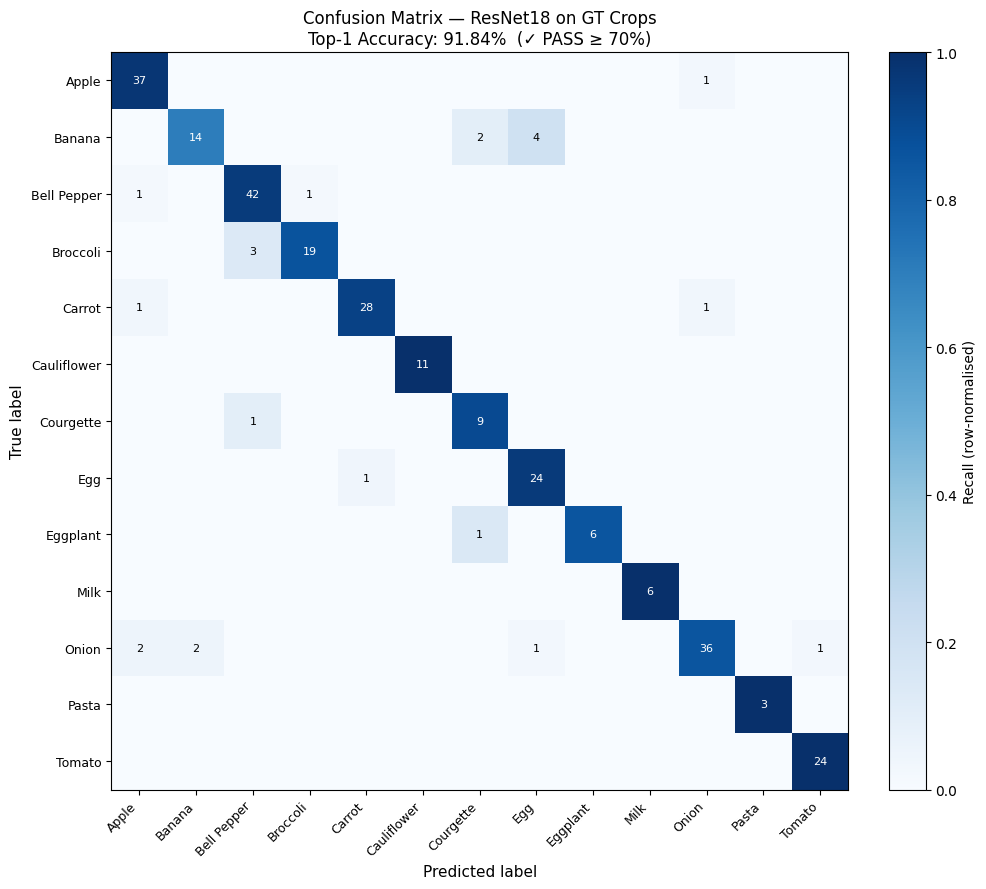

Saved → confusion_matrix.png


In [17]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display as ipy_display

fig, ax = plt.subplots(figsize=(11, 9))

# Normalize so each row sums to 1 (recall view)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Recall (row-normalised)")

tick_marks = np.arange(num_cls)
ax.set_xticks(tick_marks);  ax.set_xticklabels(class_names_rec, rotation=45, ha="right", fontsize=9)
ax.set_yticks(tick_marks);  ax.set_yticklabels(class_names_rec, fontsize=9)

# Annotate with raw counts
thresh = cm_norm.max() / 2.0
for i in range(num_cls):
    for j in range(num_cls):
        val = cm[i, j]
        if val > 0:
            color = "white" if cm_norm[i, j] > thresh else "black"
            ax.text(j, i, str(val), ha="center", va="center", fontsize=8, color=color)

ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title(
    f"Confusion Matrix — ResNet18 on GT Crops\n"
    f"Top-1 Accuracy: {top1_acc*100:.2f}%  "
    f"({'✓ PASS ≥ 70%' if top1_acc >= 0.70 else '✗ FAIL'})",
    fontsize=12
)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
ipy_display(fig)
plt.close(fig)
print("Saved → confusion_matrix.png")


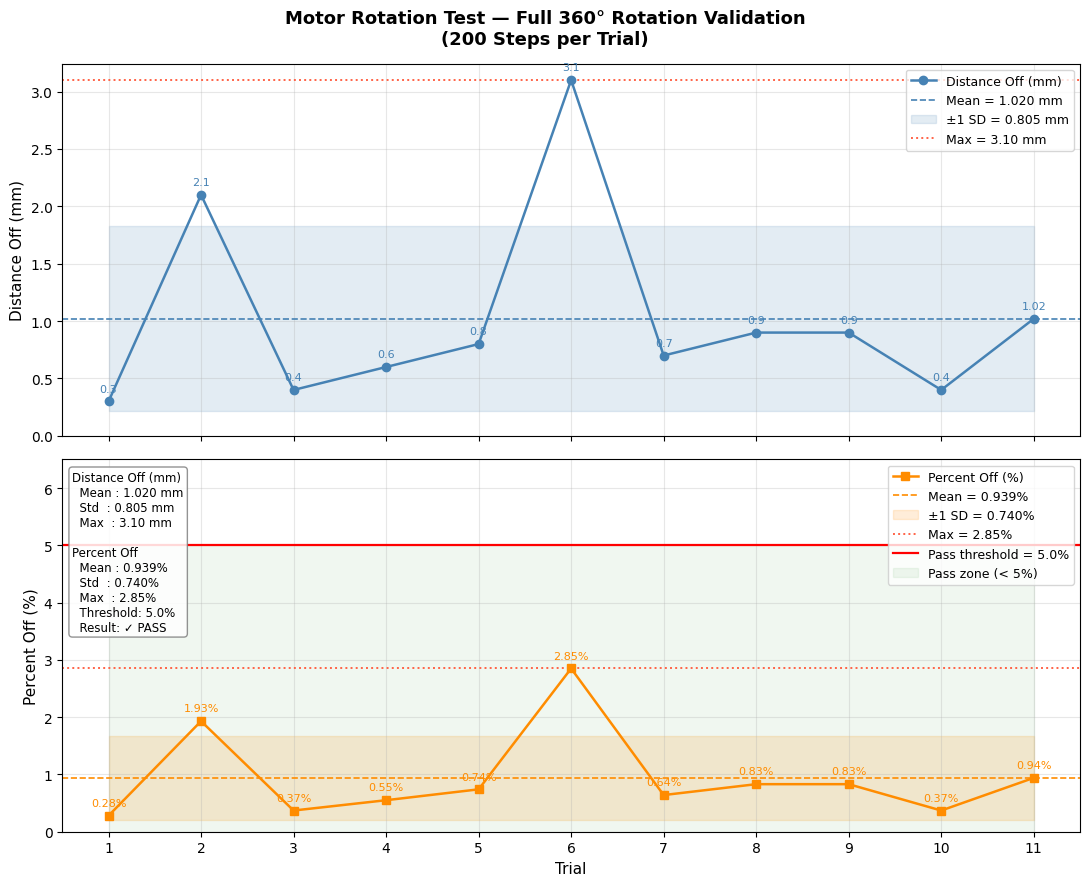


Summary — n=11 trials
  Distance Off: mean=1.020 mm, std=0.805 mm, max=3.10 mm
  Percent Off : mean=0.939%, std=0.740%, max=2.85%
  ≤5% requirement: ✓ PASS


In [22]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
distance_off = np.array([0.3, 2.1, 0.4, 0.6, 0.8, 3.1, 0.7, 0.9, 0.9, 0.4, 1.02])
percent_off  = np.array([0.28, 1.93, 0.37, 0.55, 0.74, 2.85, 0.64, 0.83, 0.83, 0.37, 0.94])

trials = np.arange(1, len(distance_off) + 1)

# ── Statistics ────────────────────────────────────────────────────────────────
mean_dist  = distance_off.mean()
std_dist   = distance_off.std()
max_dist   = distance_off.max()

mean_pct   = percent_off.mean()
std_pct    = percent_off.std()
max_pct    = percent_off.max()

PASS_THRESH_PCT = 5.0   # requirement: ≤ 5 % variation

# ── Figure: two subplots ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
fig.suptitle("Motor Rotation Test — Full 360° Rotation Validation\n(200 Steps per Trial)",
             fontsize=13, fontweight="bold")

# ---- top: Distance off (mm) ------------------------------------------------
ax1.plot(trials, distance_off, marker='o', color='steelblue', linewidth=1.8,
         label='Distance Off (mm)', zorder=3)
ax1.axhline(mean_dist, color='steelblue', linestyle='--', linewidth=1.2,
            label=f'Mean = {mean_dist:.3f} mm')
ax1.fill_between(trials,
                 mean_dist - std_dist, mean_dist + std_dist,
                 color='steelblue', alpha=0.15,
                 label=f'±1 SD = {std_dist:.3f} mm')
ax1.axhline(max_dist, color='tomato', linestyle=':', linewidth=1.4,
            label=f'Max = {max_dist:.2f} mm')

ax1.set_ylabel("Distance Off (mm)", fontsize=11)
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Annotate each point
for x, y in zip(trials, distance_off):
    ax1.annotate(f'{y}', (x, y), textcoords='offset points',
                 xytext=(0, 7), ha='center', fontsize=8, color='steelblue')

# ---- bottom: Percent off (%) -----------------------------------------------
ax2.plot(trials, percent_off, marker='s', color='darkorange', linewidth=1.8,
         label='Percent Off (%)', zorder=3)
ax2.axhline(mean_pct, color='darkorange', linestyle='--', linewidth=1.2,
            label=f'Mean = {mean_pct:.3f}%')
ax2.fill_between(trials,
                 mean_pct - std_pct, mean_pct + std_pct,
                 color='darkorange', alpha=0.15,
                 label=f'±1 SD = {std_pct:.3f}%')
ax2.axhline(max_pct, color='tomato', linestyle=':', linewidth=1.4,
            label=f'Max = {max_pct:.2f}%')
ax2.axhline(PASS_THRESH_PCT, color='red', linestyle='-', linewidth=1.6,
            label=f'Pass threshold = {PASS_THRESH_PCT}%', zorder=2)

# Shade the passing zone
ax2.fill_between(trials, 0, PASS_THRESH_PCT,
                 color='green', alpha=0.06, label='Pass zone (< 5%)')

ax2.set_ylabel("Percent Off (%)", fontsize=11)
ax2.set_xlabel("Trial", fontsize=11)
ax2.set_ylim(bottom=0, top=max(PASS_THRESH_PCT * 1.3, max_pct * 1.3))
ax2.set_xticks(trials)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

for x, y in zip(trials, percent_off):
    ax2.annotate(f'{y}%', (x, y), textcoords='offset points',
                 xytext=(0, 7), ha='center', fontsize=8, color='darkorange')

# ── Summary text box ─────────────────────────────────────────────────────────
all_pass = max_pct < PASS_THRESH_PCT
verdict  = "✓ PASS" if all_pass else "✗ FAIL"
verdict_color = "green" if all_pass else "red"

summary = (
    f"Distance Off (mm)\n"
    f"  Mean : {mean_dist:.3f} mm\n"
    f"  Std  : {std_dist:.3f} mm\n"
    f"  Max  : {max_dist:.2f} mm\n\n"
    f"Percent Off\n"
    f"  Mean : {mean_pct:.3f}%\n"
    f"  Std  : {std_pct:.3f}%\n"
    f"  Max  : {max_pct:.2f}%\n"
    f"  Threshold: {PASS_THRESH_PCT}%\n"
    f"  Result: {verdict}"
)
ax2.text(0.01, 0.97, summary, transform=ax2.transAxes,
         fontsize=8.5, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

plt.tight_layout()
plt.savefig("motor_rotation_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSummary — n={len(distance_off)} trials")
print(f"  Distance Off: mean={mean_dist:.3f} mm, std={std_dist:.3f} mm, max={max_dist:.2f} mm")
print(f"  Percent Off : mean={mean_pct:.3f}%, std={std_pct:.3f}%, max={max_pct:.2f}%")
print(f"  ≤5% requirement: {verdict}")


/tmp/ipykernel_7053/3705215156.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7053/3705215156.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("comm_latency_validation_table.png", dpi=150, bbox_inches="tight",
/home/tony/anaconda3/envs/CS444/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


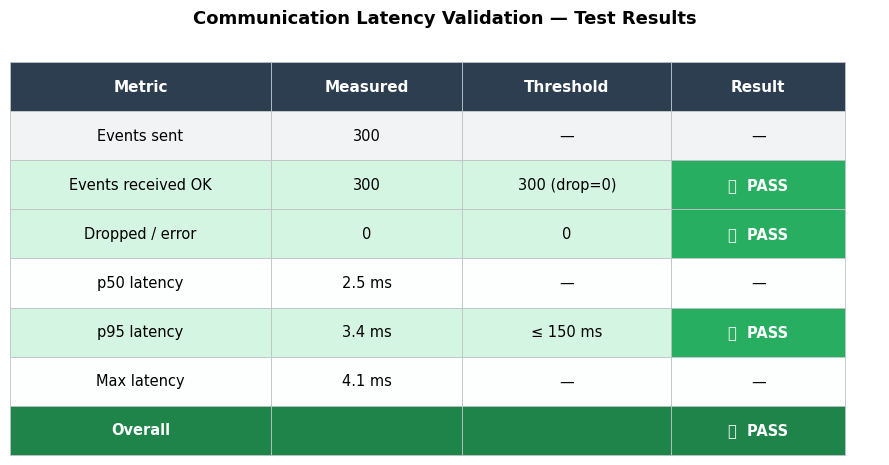

Saved → comm_latency_validation_table.png


In [23]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# ── Table data ────────────────────────────────────────────────────────────────
headers = ["Metric", "Measured", "Threshold", "Result"]

rows = [
    ["Events sent",        "300",      "—",           "—"],
    ["Events received OK", "300",      "300 (drop=0)", "✅  PASS"],
    ["Dropped / error",    "0",        "0",            "✅  PASS"],
    ["p50 latency",        "2.5 ms",   "—",            "—"],
    ["p95 latency",        "3.4 ms",   "≤ 150 ms",     "✅  PASS"],
    ["Max latency",        "4.1 ms",   "—",            "—"],
    ["Overall",            "",         "",             "✅  PASS"],
]

# ── Colour scheme ─────────────────────────────────────────────────────────────
HEADER_BG   = "#2C3E50"
HEADER_FG   = "white"
PASS_BG     = "#D5F5E3"   # light green  – rows with PASS
NEUTRAL_BG  = "#F2F3F4"   # light grey   – info-only rows
OVERALL_BG  = "#1E8449"   # dark green   – last row
OVERALL_FG  = "white"
ALT_BG      = "#FDFEFE"   # white-ish alternating rows

col_widths = [0.30, 0.22, 0.24, 0.20]   # fractions of figure width (sum ≈ 1)

fig_w, row_h = 9, 0.52
n_rows = len(rows)
fig_h  = row_h * (n_rows + 1) + 0.4     # +1 for header

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")
fig.patch.set_facecolor("white")

# ── Helper: draw one cell ─────────────────────────────────────────────────────
def draw_cell(ax, x, y, w, h, text, bg, fg="black", fontsize=11,
              bold=False, align="center"):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="square,pad=0",
        linewidth=0.6, edgecolor="#BDC3C7",
        facecolor=bg, transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(
        x + w / 2 if align == "center" else x + 0.01,
        y + h / 2,
        text,
        transform=ax.transAxes,
        ha=align, va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        color=fg,
        clip_on=False,
    )

# ── Layout: work top-to-bottom in axes coords ─────────────────────────────────
total_h  = 1.0                          # axes height = 1 in transAxes
cell_h   = total_h / (n_rows + 1)      # header + data rows

xs = [sum(col_widths[:i]) for i in range(len(col_widths))]   # left edge of each col

# Header row
y_hdr = 1.0 - cell_h
for ci, (label, cw, cx) in enumerate(zip(headers, col_widths, xs)):
    draw_cell(ax, cx, y_hdr, cw, cell_h, label,
              bg=HEADER_BG, fg=HEADER_FG, fontsize=11, bold=True)

# Data rows
for ri, row in enumerate(rows):
    y = y_hdr - cell_h * (ri + 1)
    is_pass    = "PASS" in row[-1]
    is_overall = ri == len(rows) - 1

    for ci, (cell_text, cw, cx) in enumerate(zip(row, col_widths, xs)):
        if is_overall:
            bg = OVERALL_BG
            fg = OVERALL_FG
            bold = True
        elif is_pass and ci == len(row) - 1:
            bg   = "#27AE60"    # green result cell
            fg   = "white"
            bold = True
        elif is_pass:
            bg   = PASS_BG
            fg   = "black"
            bold = False
        else:
            bg   = NEUTRAL_BG if ri % 2 == 0 else ALT_BG
            fg   = "black"
            bold = False

        draw_cell(ax, cx, y, cw, cell_h, cell_text,
                  bg=bg, fg=fg, fontsize=10.5, bold=bold)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.suptitle("Communication Latency Validation — Test Results",
             fontsize=13, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("comm_latency_validation_table.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved → comm_latency_validation_table.png")


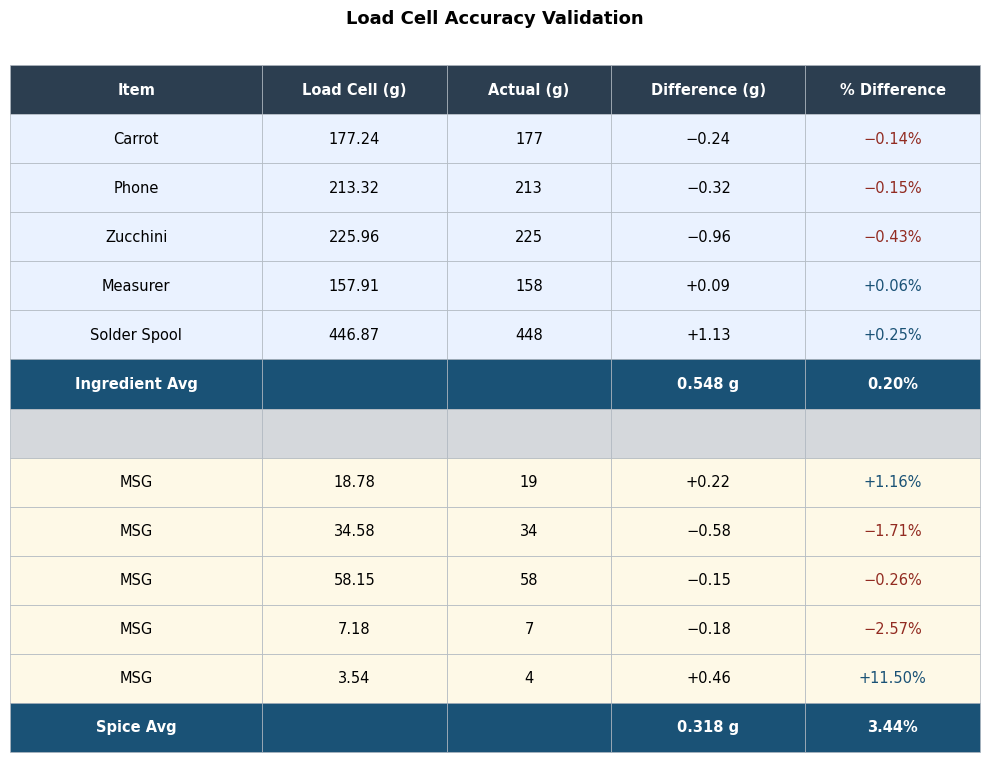

Saved → load_cell_validation_table.png


In [24]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Colour palette ────────────────────────────────────────────────────────────
HEADER_BG   = "#2C3E50";  HEADER_FG  = "white"
SEC_BG      = "#1A5276";  SEC_FG     = "white"   # section-summary rows
ROW_A       = "#EAF2FF"                            # ingredient section rows
ROW_B       = "#FEF9E7"                            # spice section rows
DIVIDER_BG  = "#D5D8DC"                            # blank separator rows

# ── Data ──────────────────────────────────────────────────────────────────────
# Each row: (label, load_cell, actual, diff, pct_diff, section)
# section: "ingredient" | "spice" | "separator" | "summary_ing" | "summary_spc"
headers = ["Item", "Load Cell (g)", "Actual (g)", "Difference (g)", "% Difference"]

data_rows = [
    # ── Ingredient objects ────────────────────────────────────────────────────
    ("Carrot",          "177.24", "177",  "−0.24", "−0.14%", "ingredient"),
    ("Phone",           "213.32", "213",  "−0.32", "−0.15%", "ingredient"),
    ("Zucchini",        "225.96", "225",  "−0.96", "−0.43%", "ingredient"),
    ("Measurer",        "157.91", "158",  "+0.09",  "+0.06%", "ingredient"),
    ("Solder Spool",    "446.87", "448",  "+1.13",  "+0.25%", "ingredient"),
    # summary
    ("Ingredient Avg",  "",       "",     "0.548 g", "0.20%",  "summary_ing"),
    # separator
    ("", "", "", "", "", "separator"),
    # ── Spice (MSG) samples ───────────────────────────────────────────────────
    ("MSG",  "18.78", "19",  "+0.22", "+1.16%", "spice"),
    ("MSG",  "34.58", "34",  "−0.58", "−1.71%", "spice"),
    ("MSG",  "58.15", "58",  "−0.15", "−0.26%", "spice"),
    ("MSG",   "7.18",  "7",  "−0.18", "−2.57%", "spice"),
    ("MSG",   "3.54",  "4",  "+0.46", "+11.50%","spice"),
    # summary
    ("Spice Avg",       "",       "",     "0.318 g", "3.44%",  "summary_spc"),
]

col_widths = [0.26, 0.19, 0.17, 0.20, 0.18]

# ── Figure setup ──────────────────────────────────────────────────────────────
fig_w  = 10
row_h  = 0.50
n_rows = len(data_rows)
fig_h  = row_h * (n_rows + 1) + 0.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")
fig.patch.set_facecolor("white")

def draw_cell(ax, x, y, w, h, text, bg, fg="black",
              fontsize=10.5, bold=False, align="center"):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="square,pad=0",
        linewidth=0.5, edgecolor="#AEB6BF",
        facecolor=bg, transform=ax.transAxes, clip_on=False))
    ax.text(
        x + w / 2 if align == "center" else x + 0.012,
        y + h / 2, text,
        transform=ax.transAxes, ha=align, va="center",
        fontsize=fontsize, fontweight="bold" if bold else "normal",
        color=fg, clip_on=False)

xs     = [sum(col_widths[:i]) for i in range(len(col_widths))]
cell_h = 1.0 / (n_rows + 1)

# Header
y_hdr = 1.0 - cell_h
for label, cw, cx in zip(headers, col_widths, xs):
    draw_cell(ax, cx, y_hdr, cw, cell_h, label,
              bg=HEADER_BG, fg=HEADER_FG, bold=True)

# Data rows
for ri, (item, lc, act, diff, pct, sec) in enumerate(data_rows):
    y = y_hdr - cell_h * (ri + 1)
    vals = [item, lc, act, diff, pct]

    if sec == "separator":
        for cw, cx in zip(col_widths, xs):
            draw_cell(ax, cx, y, cw, cell_h, "", bg=DIVIDER_BG)
        continue

    if sec == "summary_ing":
        bg, fg, bold = SEC_BG, SEC_FG, True
    elif sec == "summary_spc":
        bg, fg, bold = SEC_BG, SEC_FG, True
    elif sec == "ingredient":
        bg, fg, bold = ROW_A, "black", False
    else:   # spice
        bg, fg, bold = ROW_B, "black", False

    for ci, (val, cw, cx) in enumerate(zip(vals, col_widths, xs)):
        # colour the % diff cell red/green for sign
        cell_bg = bg
        cell_fg = fg
        if ci == 4 and sec in ("ingredient", "spice") and val not in ("", "—"):
            cell_fg = "#1A5276" if val.startswith("+") else "#922B21"
        draw_cell(ax, cx, y, cw, cell_h, val,
                  bg=cell_bg, fg=cell_fg,
                  bold=bold or (ci == 0 and sec.startswith("summary")))

ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
fig.suptitle("Load Cell Accuracy Validation", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("load_cell_validation_table.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → load_cell_validation_table.png")


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Colour palette ────────────────────────────────────────────────────────────
HEADER_BG  = "#2C3E50";  HEADER_FG  = "white"
ROW_EVEN   = "#EAF2FF"
ROW_ODD    = "#FDFEFE"
SUMMARY_BG = "#1A5276";  SUMMARY_FG = "white"

# ── Data ──────────────────────────────────────────────────────────────────────
headers = ["Weight (g)", "IR Distance", "IR %", "Weight %", "% Difference"]

rows = [
    ("0",       "153",   "0%",    "0.00%",    "0.00%"),
    ("44",      "132.5", "19%",  "19.01%",   "+0.37%"),
    ("89.48",   "113",   "38%",  "38.66%",   "−0.85%"),
    ("124.48",  "91.9",  "58%",  "53.78%",   "+3.97%"),
    ("164.48",  "73.2",  "75%",  "71.06%",   "+4.37%"),
    ("231.48",  "47.2",  "100%", "100.00%",  "0.00%"),
]

summary = ("Average", "", "", "", "1.59%")

col_widths = [0.20, 0.18, 0.14, 0.18, 0.22]

# ── Figure setup ──────────────────────────────────────────────────────────────
fig_w  = 10
row_h  = 0.52
n_rows = len(rows) + 1   # data + summary
fig_h  = row_h * (n_rows + 1) + 0.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")
fig.patch.set_facecolor("white")

def draw_cell(ax, x, y, w, h, text, bg, fg="black",
              fontsize=10.5, bold=False):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="square,pad=0",
        linewidth=0.5, edgecolor="#AEB6BF",
        facecolor=bg, transform=ax.transAxes, clip_on=False))
    ax.text(
        x + w / 2, y + h / 2, text,
        transform=ax.transAxes, ha="center", va="center",
        fontsize=fontsize, fontweight="bold" if bold else "normal",
        color=fg, clip_on=False)

xs     = [sum(col_widths[:i]) for i in range(len(col_widths))]
cell_h = 1.0 / (n_rows + 1)

# Header
y_hdr = 1.0 - cell_h
for label, cw, cx in zip(headers, col_widths, xs):
    draw_cell(ax, cx, y_hdr, cw, cell_h, label,
              bg=HEADER_BG, fg=HEADER_FG, bold=True)

# Data rows
for ri, row in enumerate(rows):
    y  = y_hdr - cell_h * (ri + 1)
    bg = ROW_EVEN if ri % 2 == 0 else ROW_ODD
    for ci, (val, cw, cx) in enumerate(zip(row, col_widths, xs)):
        fg = "black"
        if ci == 4 and val not in ("0.00%", ""):
            fg = "#1A5276" if val.startswith("+") else "#922B21"
        draw_cell(ax, cx, y, cw, cell_h, val, bg=bg, fg=fg)

# Summary row
y_sum = y_hdr - cell_h * (len(rows) + 1)
for ci, (val, cw, cx) in enumerate(zip(summary, col_widths, xs)):
    draw_cell(ax, cx, y_sum, cw, cell_h, val,
              bg=SUMMARY_BG, fg=SUMMARY_FG, bold=True)

ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
fig.suptitle("IR Distance Sensor vs. Weight Validation", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ir_sensor_validation_table.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → ir_sensor_validation_table.png")
